# Entregable 3: Fine-tuning de CLIP-RN50 para búsqueda semántica imagen-texto sobre Flickr8k


El dataset Flickr8k contiene 8,000 imágenes extraídas de Flickr, cada una anotada con cinco descripciones en lenguaje natural escritas por personas. Las imágenes representan escenas cotidianas, personas, animales y diversas situaciones al aire libre, ofreciendo una amplia variedad de contextos para el entrenamiento de modelos visión-lenguaje.

El conjunto se divide en tres particiones estándar: 6,000 imágenes para entrenamiento, 1,000 para validación y 1,000 para test. Aunque es modesto en tamaño comparado con datasets como COCO, resulta ideal para experimentar con fine-tuning contrastivo dado su bajo coste computacional y la calidad de sus anotaciones.

## 1. Configuración del entorno

En esta sección, se prepara el entorno para el experimento. Se reinstala Pillow a una versión estable, ya que la versión predeterminada en Colab a veces presenta problemas. Luego, se instalan las librerías necesarias como OpenCLIP, datasets y huggingface_hub. Es importante destacar que aunque se instala transformers, el modelo principal no se carga desde allí, sino que se utiliza una utilidad específica (get_cosine_schedule_with_warmup) de transformers para el planificador de la tasa de aprendizaje.

In [ ]:
import subprocess, sys
def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)

pip("--force-reinstall", "--no-deps", "Pillow==10.4.0")
pip("-U", "open_clip_torch", "datasets", "huggingface_hub", "tqdm", "scikit-learn", "seaborn", "transformers")

print("  Instalación completada.")
print("  Por favor, reinicie el entorno ")
print("  Luego, podrá continuar con la ejecución del cuaderno.")

  Instalación completada.
  Por favor, reinicie el entorno 
  Luego, podrá continuar con la ejecución del cuaderno.


In [ ]:
import subprocess, sys
import os
import json
import random
import math
import time
import io
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from datasets import load_dataset
import open_clip
from transformers import get_cosine_schedule_with_warmup
from PIL import Image

In [ ]:
# Se fijan las semillas para asegurar la reproducibilidad de los resultados.
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Se selecciona la GPU si está disponible; de lo contrario, se usa la CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"El entorno está configurado para usar: {DEVICE}")
print(f"Versión de PyTorch: {torch.__version__}")
print(f"Versión de OpenCLIP: {open_clip.__version__ if hasattr(open_clip, '__version__') else 'instalado'}")
print(f"Versión de Pillow: {Image.__version__ if hasattr(Image,'__version__') else 'OK'}")

El entorno está configurado para usar: cuda
Versión de PyTorch: 2.11.0+cu128
Versión de OpenCLIP: 3.3.0
Versión de Pillow: 11.3.0


## 2. Configuración del experimento

Aquí se definen los ajustes clave para el proceso de fine-tuning. Se especifica el modelo CLIP-RN50 de OpenAI, así como detalles del dataset, el tamaño de las imágenes, la longitud máxima de los textos y otros parámetros esenciales para el entrenamiento, como el tamaño del batch y la tasa de aprendizaje. Estos valores son fundamentales para guiar el aprendizaje del modelo.

In [ ]:
CFG = {
    "model_arch"     : "RN50",
    "model_pretrain" : "openai",
    "nombre_dataset"   : "jxie/flickr8k",
    "direccion_output"     : "./clip-rn50-flickr8k-ft",
    "tamanho_imagen"     : 224,
    "long_max_texto"   : 77,
    "train_bs"       : 32,
    "grad_accum"     : 4,
    "eval_bs"        : 128,
    "lr"             : 1e-5,
    "weight_decay"   : 0.1,
    "betas"          : (0.9, 0.98),
    "warmup_ratio"   : 0.05,
    "epochs"         : 20,
    "max_grad_norm"  : 1.0,
    "fp16"           : True,
    "num_workers"    : 0,
    "eval_every"     : 1,
}
os.makedirs(CFG["direccion_output"], exist_ok=True)
for k, v in CFG.items():
    print(f"{k:>15}: {v}")

     model_arch: RN50
 model_pretrain: openai
 nombre_dataset: jxie/flickr8k
direccion_output: ./clip-rn50-flickr8k-ft
 tamanho_imagen: 224
 long_max_texto: 77
       train_bs: 32
     grad_accum: 4
        eval_bs: 128
             lr: 1e-05
   weight_decay: 0.1
          betas: (0.9, 0.98)
   warmup_ratio: 0.05
         epochs: 20
  max_grad_norm: 1.0
           fp16: True
    num_workers: 0
     eval_every: 1


## 3. Descarga de Flickr8k y preparación de datos

En esta fase, se descarga el dataset Flickr8k y se ajusta su estructura. Dado que los datasets en Hugging Face pueden variar, se usan funciones auxiliares para asegurar que las imágenes y descripciones se extraigan de manera uniforme, sin importar el formato original. Esto garantiza la consistencia de los datos para el entrenamiento. Además, se realizan los splits: 6000 de entrenamiento, 1000 de validación y 1000 de test

In [ ]:
dataset = load_dataset(CFG["nombre_dataset"])
print(dataset)
print("\nColumnas:", dataset[list(dataset.keys())[0]].column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})

Columnas: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4']


In [ ]:
primera_particion = dataset[list(dataset.keys())[0]]
cols = primera_particion.column_names

IMAGE_KEY = next((c for c in cols if c.lower() in ("image","img","picture","jpg")), None)
assert IMAGE_KEY is not None, f"No se encontró columna de imagen en {cols}"

cols_descripciones = sorted([c for c in cols if c.lower().startswith("caption") and c.lower() != "captions"])
if not cols_descripciones:
    cols_descripciones = [c for c in cols if c.lower() in ("caption","captions","text")]
assert cols_descripciones, f"No se encontraron columnas de caption en {cols}"

def get_caps(ex):
    if len(cols_descripciones) > 1:
        return [ex[c] for c in cols_descripciones if ex[c]]
    c = ex[cols_descripciones[0]]
    return c if isinstance(c, list) else [c]

def get_image(ex):
    img = ex[IMAGE_KEY]
    if isinstance(img, Image.Image):
        return img.convert("RGB")
    if isinstance(img, dict) and img.get("bytes"):
        return Image.open(io.BytesIO(img["bytes"])).convert("RGB")
    if isinstance(img, dict) and img.get("path"):
        return Image.open(img["path"]).convert("RGB")
    return Image.fromarray(np.asarray(img)).convert("RGB")

splits = set(dataset.keys())
datos_entren, datos_val, datos_test = dataset["train"], dataset["validation"], dataset["test"]

print(f"Clave de imagen identificada: {IMAGE_KEY}")
print(f"Columnas de descripción identificadas: {cols_descripciones}")
print(f"Distribución de splits: train={len(datos_entren)} - validación={len(datos_val)} - test={len(datos_test)}")

Clave de imagen identificada: image
Columnas de descripción identificadas: ['caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4']
Distribución de splits: train=6000 - validación=1000 - test=1000


### 3.1 Visualización y estadísticas de descripciones

Se muestran algunas imágenes del dataset con sus descripciones para tener una idea visual del contenido. También se analiza la distribución de la longitud de las descripciones, lo que nos ayuda a entender cómo encajan en el límite de tokens del modelo CLIP.

Para visualizar el dataset, se muestran seis imágenes seleccionadas al azar del split de entrenamiento. Cada imagen se acompaña de su primera descripción disponible, sirviendo como título. Esto nos da una idea rápida del tipo de contenido que estamos manejando.

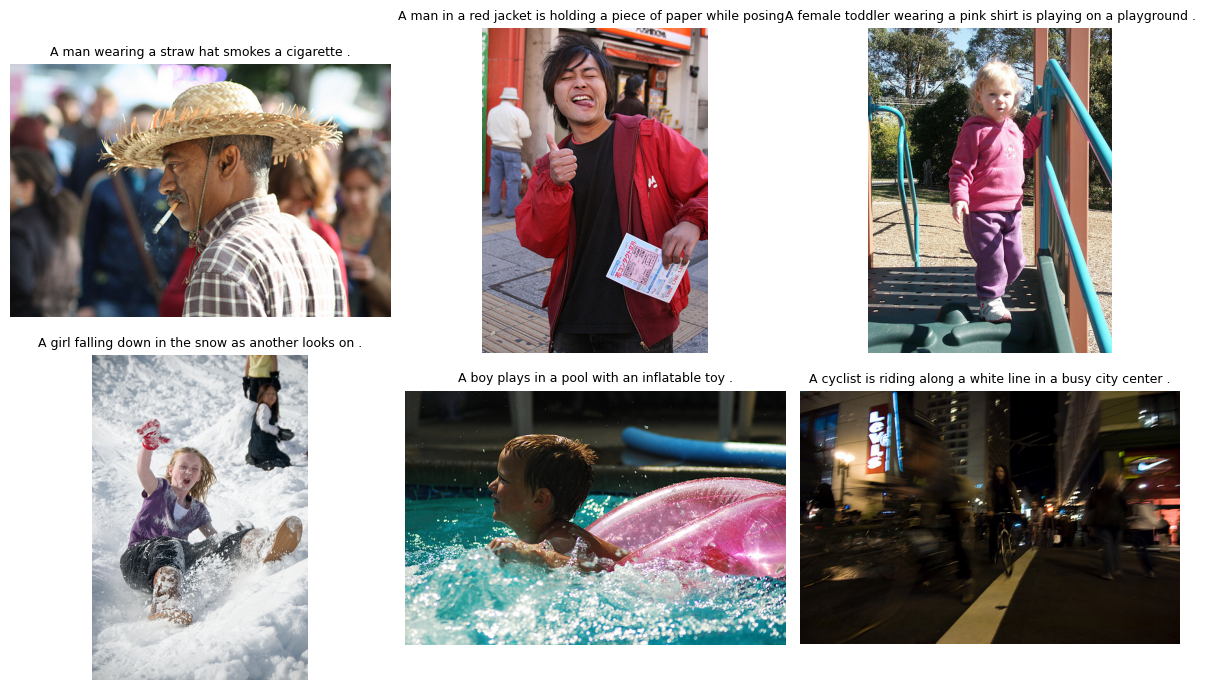

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, i in zip(axes.ravel(), random.sample(range(len(datos_entren)), 6)):
    ex = datos_entren[i]
    ax.imshow(get_image(ex)); ax.axis("off")
    cap = get_caps(ex)[0]
    ax.set_title(cap[:70] + ("..." if len(cap)>70 else ""), fontsize=9)
plt.tight_layout(); plt.show()

Se analiza la distribución de la longitud de las descripciones (en número de palabras) para los primeros 2000 ejemplos del split de entrenamiento. Esto es crucial para asegurar que las descripciones se ajusten al límite de 77 tokens del tokenizador BPE de CLIP. Observamos que la longitud media es de aproximadamente 11 palabras y el percentil 95 está en 20, lo cual es adecuado ya que el límite de 77 tokens permite entre 55 y 60 palabras.

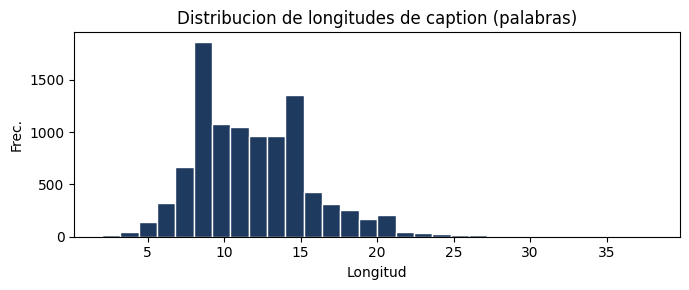

media=11.8, p95=19, max=38


In [ ]:
longitudes = []
for i in range(min(2000, len(datos_entren))):
    for c in get_caps(datos_entren[i]):
        longitudes.append(len(c.split()))
plt.figure(figsize=(7,3))
plt.hist(longitudes, bins=30, color="#1E3A5F", edgecolor="white")
plt.title("Distribucion de longitudes de caption (palabras)")
plt.xlabel("Longitud"); plt.ylabel("Frec.")
plt.tight_layout(); plt.show()
print(f"media={np.mean(longitudes):.1f}, p95={np.percentile(longitudes,95):.0f}, max={np.max(longitudes)}")


La función create_model_and_transforms de OpenCLIP devuelve el modelo, un preprocesador para entrenamiento y otro para evaluación. Para el fine-tuning, se utiliza el preprocesador de evaluación en ambos splits. Esto se hace para mantener la consistencia entre la vista de cada imagen y la distribución de evaluación, evitando augmentations aleatorios que podrían ser contraproducentes.


In [ ]:
model, _, preprocess = open_clip.create_model_and_transforms(
    CFG["model_arch"], pretrained=CFG["model_pretrain"]
)
model = model.to(DEVICE)
tokenizer = open_clip.get_tokenizer(CFG["model_arch"])

n_parametros  = sum(p.numel() for p in model.parameters())
n_visual  = sum(p.numel() for p in model.visual.parameters())
modulos_texto = ["transformer", "token_embedding", "positional_embedding",
                 "ln_final", "text_projection"]
n_textual = 0
for nombre in modulos_texto:
    attr = getattr(model, nombre, None)
    if attr is None: continue
    if isinstance(attr, torch.nn.Parameter):
        n_textual += attr.numel()
    else:
        n_textual += sum(p.numel() for p in attr.parameters())

print(f"Modelo              : CLIP-{CFG['model_arch']} (pretrain={CFG['model_pretrain']})")
print(f"Parametros totales  : {n_parametros/1e6:.2f} M")
print(f"  - encoder visual  : {n_visual/1e6:.2f} M  (ResNet-50 modificada + attnpool)")
print(f"  - encoder textual : {n_textual/1e6:.2f} M  (Transformer 12L causal)")
print(f"Dim. embedding      : {model.visual.output_dim}")
print(f"escala_logit (1/tau) : {model.logit_scale.exp().item():.2f}")
print(f"Resolucion entrada  : {CFG['tamanho_imagen']} x {CFG['tamanho_imagen']}")
print(f"Longitud contexto   : {getattr(tokenizer, 'context_length', 77)} tokens")


open_clip_model.safetensors:   0%|          | 0.00/408M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Modelo              : CLIP-RN50 (pretrain=openai)
Parametros totales  : 102.01 M
  - encoder visual  : 38.32 M  (ResNet-50 modificada + attnpool)
  - encoder textual : 63.69 M  (Transformer 12L causal)
Dim. embedding      : 1024
escala_logit (1/tau) : 100.00
Resolucion entrada  : 224 x 224
Longitud contexto   : 77 tokens


## 5. Preparación de Datasets y DataLoaders

En esta sección, se configuran los Dataset y DataLoader que alimentarán al modelo durante el entrenamiento y la evaluación. OpenCLIP ya nos proporciona herramientas de preprocesamiento para imágenes y textos que se usan aquí para transformar los datos en el formato adecuado para el modelo.

Cada elemento del dataset genera un par (imagen, descripción). Durante el entrenamiento, se selecciona aleatoriamente una de las cinco descripciones disponibles para cada imagen. Esta estrategia actúa como una forma de regularización suave, permitiendo que el modelo asocie la imagen con diferentes descripciones a lo largo de las épocas. En el modo de evaluación, se utiliza siempre la primera descripción (caps[0]) para asegurar la reproducibilidad en las comparaciones de rendimiento.

In [ ]:
class Flickr8kContrastive(Dataset):
    def __init__(self, hf_ds, preprocess, tokenizer, mode="train"):
        self.ds = hf_ds
        self.preprocess = preprocess
        self.tokenizer  = tokenizer
        self.mode = mode

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, i):
        ex   = self.ds[i]
        img  = get_image(ex)
        caps = get_caps(ex)
        cap  = random.choice(caps) if self.mode == "train" else caps[0]

        pix    = self.preprocess(img)
        tokens = self.tokenizer([cap])[0]
        return {"pixel_values": pix, "tokens": tokens}

def collate(batch):
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch]),
        "tokens"      : torch.stack([b["tokens"]       for b in batch]),
    }

cargador_entren = DataLoader(
    Flickr8kContrastive(datos_entren, preprocess, tokenizer, "train"),
    batch_size=CFG["train_bs"], shuffle=True, collate_fn=collate,
    num_workers=CFG["num_workers"], pin_memory=False, drop_last=True,
)
cargador_val = DataLoader(
    Flickr8kContrastive(datos_val, preprocess, tokenizer, "eval"),
    batch_size=CFG["eval_bs"], collate_fn=collate,
    num_workers=CFG["num_workers"], pin_memory=False,
)
cargador_test = DataLoader(
    Flickr8kContrastive(datos_test, preprocess, tokenizer, "eval"),
    batch_size=CFG["eval_bs"], collate_fn=collate,
    num_workers=CFG["num_workers"], pin_memory=False,
)
print(f"Se han creado {len(cargador_entren)} batches para entrenamiento, {len(cargador_val)} para validación y {len(cargador_test)} para pruebas.")

Se han creado 187 batches para entrenamiento, 8 para validación y 8 para pruebas.


In [ ]:
import gc

@torch.no_grad()
def encode_all(model, dataset, preprocess, tokenizer, bs_img=32, bs_txt=128, device=DEVICE):
    model.eval()
    embs_imagen, embs_texto, img_a_descs = [], [], []
    idx_desc = 0
    todas_descs = []

    # Se procesan las imágenes en bloques para gestionar la memoria.
    buffer_imgs = []
    for i in tqdm(range(len(dataset)), desc="Codificando imágenes"):
        ex = dataset[i]
        caps = get_caps(ex)
        img_a_descs.append(list(range(idx_desc, idx_desc + len(caps))))
        idx_desc += len(caps)
        todas_descs.extend(caps)

        buffer_imgs.append(get_image(ex))
        if len(buffer_imgs) >= bs_img:
            pix = torch.stack([preprocess(im) for im in buffer_imgs]).to(device)
            e   = model.encode_image(pix).float()
            embs_imagen.append(F.normalize(e, dim=-1).cpu())
            buffer_imgs.clear()
            del pix, e

    if buffer_imgs:
        pix = torch.stack([preprocess(im) for im in buffer_imgs]).to(device)
        e   = model.encode_image(pix).float()
        embs_imagen.append(F.normalize(e, dim=-1).cpu())
        del pix, e, buffer_imgs

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Se procesan los textos en bloques para gestionar la memoria.
    for i in tqdm(range(0, len(todas_descs), bs_txt), desc="Codificando textos"):
        batch = todas_descs[i:i+bs_txt]
        tok   = tokenizer(batch).to(device)
        e     = model.encode_text(tok).float()
        embs_texto.append(F.normalize(e, dim=-1).cpu())
        del tok, e

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return torch.cat(embs_imagen), torch.cat(embs_texto), img_a_descs

def recall_at_k(sim, gt_indices, ks=(1,5,10)):
    ranks = []
    topk = sim.topk(max(ks), dim=1).indices
    for q, correct in enumerate(gt_indices):
        correct = correct if isinstance(correct, (list, tuple, set)) else [correct]
        correct = set(correct)
        rank = next((i for i, c in enumerate(topk[q].tolist()) if c in correct), max(ks))
        ranks.append(rank)
    ranks = np.array(ranks)
    out = {f"recall {k}": float((ranks < k).mean()*100) for k in ks}
    out["MedR"] = float(np.median(ranks) + 1)
    return out

def eval_retrieval(model, dataset, preprocess, tokenizer, etiqueta="val"):
    ie, te, img_a_descs = encode_all(model, dataset, preprocess, tokenizer)
    i2t = recall_at_k(ie @ te.T, img_a_descs)
    desc_a_img = [i for i, caps in enumerate(img_a_descs) for _ in caps]
    t2i = recall_at_k(te @ ie.T, desc_a_img)
    out = {f"{etiqueta}/imagen a texto_{k}": v for k, v in i2t.items()}
    out.update({f"{etiqueta}/texto a imagen_{k}": v for k, v in t2i.items()})
    out[f"{etiqueta}/rsum"] = i2t["recall 1"] + i2t["recall 5"] + i2t["recall 10"] + t2i["recall 1"] + t2i["recall 5"] + t2i["recall 10"]
    del ie, te
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return out

## 6. Rendimiento inicial del modelo (zero-shot)

Antes de empezar el fine-tuning, se evalúa el modelo tal y como viene. Este paso es importante para establecer una base de referencia y ver cómo el modelo pre-entrenado se comporta en nuestra tarea específica sin haber aprendido nada adicional de nuestro dataset (Flickr8K).

In [ ]:
eval_zeroshot = eval_retrieval(model, datos_test, preprocess, tokenizer, etiqueta="eval_zeroshot")
for k, v in eval_zeroshot.items():
    print(f"{k:<22} {v:.2f}")


Codificando imágenes:   0%|          | 0/1000 [00:00<?, ?it/s]

Codificando textos:   0%|          | 0/40 [00:00<?, ?it/s]

eval_zeroshot/imagen a texto_recall 1 69.70
eval_zeroshot/imagen a texto_recall 5 89.80
eval_zeroshot/imagen a texto_recall 10 95.80
eval_zeroshot/imagen a texto_MedR 1.00
eval_zeroshot/texto a imagen_recall 1 51.40
eval_zeroshot/texto a imagen_recall 5 78.32
eval_zeroshot/texto a imagen_recall 10 87.00
eval_zeroshot/texto a imagen_MedR 1.00
eval_zeroshot/rsum     472.02


## 7. Entrenamiento: Fine-tuning con pérdida contrastiva

Esta sección aborda la pérdida contrastiva, la configuración del optimizador y del planificador de la tasa de aprendizaje. La función de pérdida (InfoNCE simétrica) es similar a la utilizada en CLIP original, donde cada imagen en el batch tiene un texto positivo y el resto son negativos, y viceversa para los textos. Se optimiza la media de la cross-entropy en ambas direcciones. También se configuran los grupos de weight decay y se utiliza un planificador de tasa de aprendizaje con warmup de tipo coseno. Finalmente, se habilita el uso de Automatic Mixed Precision (AMP) para entrenar con FP16, aprovechando las capacidades de las GPUs para acelerar el proceso.

In [ ]:
def contrastive_loss(logits_i2t):
    N = logits_i2t.shape[0]
    targets = torch.arange(N, device=logits_i2t.device)
    loss_i = F.cross_entropy(logits_i2t,   targets)
    loss_t = F.cross_entropy(logits_i2t.t(), targets)
    return (loss_i + loss_t) / 2

In [ ]:
# Optimizador y planificador de tasa de aprendizaje
pasos_por_epoca = math.ceil(len(cargador_entren) / CFG["grad_accum"])
pasos_totales     = pasos_por_epoca * CFG["epochs"]
pasos_warmup    = int(pasos_totales * CFG["warmup_ratio"])

def get_lr(name):
    if "visual_projection" in name or "text_projection" in name:
        return CFG["lr"] * 3.0
    if "logit_scale" in name:
        return CFG["lr"] * 3.0
    if "visual.attnpool" in name:
        return CFG["lr"] * 1.0
    if "visual.layer4" in name or "visual.layer3" in name:
        return CFG["lr"] * 1.0
    if "visual.layer2" in name:
        return CFG["lr"] * 0.3
    if "visual.layer1" in name or "visual.conv1" in name or "visual.bn1" in name:
        return CFG["lr"] * 0.1
    return CFG["lr"]

sin_decaimiento = ("bias", "ln_", "bn", "LayerNorm.weight", "BatchNorm")
groups = {}
for name, p in model.named_parameters():
    lr = get_lr(name)
    wd = 0.0 if any(nd in name for nd in sin_decaimiento) else CFG["weight_decay"]
    groups.setdefault((lr, wd), []).append(p)

params = [{"params": ps, "lr": lr, "weight_decay": wd}
          for (lr, wd), ps in groups.items()]

optimizador = torch.optim.AdamW(params, lr=CFG["lr"], betas=CFG["betas"])
planificador = get_cosine_schedule_with_warmup(optimizador, pasos_warmup, pasos_totales)

# Configuración para Automatic Mixed Precision (AMP) para versiones recientes de PyTorch.
try:
    escalador = torch.amp.GradScaler("cuda", enabled=CFG["fp16"] and torch.cuda.is_available())
    _amp_ctx = lambda: torch.amp.autocast("cuda", enabled=CFG["fp16"] and torch.cuda.is_available())
except AttributeError:
    escalador = torch.cuda.amp.GradScaler(enabled=CFG["fp16"] and torch.cuda.is_available())
    _amp_ctx = lambda: torch.cuda.amp.autocast(enabled=CFG["fp16"] and torch.cuda.is_available())

print(f"Pasos por época: {pasos_por_epoca}  Pasos totales: {pasos_totales}  Pasos de warmup: {pasos_warmup}")

Pasos por época: 47  Pasos totales: 940  Pasos de warmup: 47


In [ ]:
historial = {"perdida_entren": [], "perdida_val": [], "val_rsum": [], "val_imagen a texto_recall1": [], "val_texto a imagen_recall1": []}
mejor_rsum = -1
ruta_mejor = Path(CFG["direccion_output"]) / "best"
ruta_mejor.mkdir(parents=True, exist_ok=True)

for epoch in range(1, CFG["epochs"] + 1):
    model.train()
    perdida_entren_acum, conteo_entren = 0.0, 0
    optimizador.zero_grad(set_to_none=True)
    barra_prog = tqdm(cargador_entren, desc=f"Época {epoch}/{CFG['epochs']} (Entrenamiento)")

    for step, batch in enumerate(barra_prog, 1):
        pixel_values = batch["pixel_values"].to(DEVICE, non_blocking=True)
        tokens       = batch["tokens"].to(DEVICE, non_blocking=True)

        with _amp_ctx():
            feat_imagen = model.encode_image(pixel_values)
            feat_texto = model.encode_text(tokens)
            feat_imagen = F.normalize(feat_imagen, dim=-1)
            feat_texto = F.normalize(feat_texto, dim=-1)
            escala_logit = model.logit_scale.exp().clamp(max=100.0)
            logits = escala_logit * feat_imagen @ feat_texto.t()
            loss   = contrastive_loss(logits) / CFG["grad_accum"]

        escalador.scale(loss).backward()
        if step % CFG["grad_accum"] == 0:
            escalador.unscale_(optimizador)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["max_grad_norm"])
            escalador.step(optimizador); escalador.update(); planificador.step()
            optimizador.zero_grad(set_to_none=True)

        perdida_entren_acum += loss.item() * CFG["grad_accum"]; conteo_entren += 1
        barra_prog.set_postfix(loss=f"{perdida_entren_acum/conteo_entren:.4f}", lr=f"{planificador.get_last_lr()[0]:.2e}")

    perdida_entren_epoca = perdida_entren_acum / conteo_entren
    historial["perdida_entren"].append(perdida_entren_epoca)

    if epoch % CFG["eval_every"] == 0 or epoch == CFG["epochs"]:
        model.eval()
        perdida_val_acum, conteo_val = 0.0, 0
        barra_val = tqdm(cargador_val, desc=f"Época {epoch}/{CFG['epochs']} (Validación)")
        for batch in barra_val:
            pixel_values = batch["pixel_values"].to(DEVICE, non_blocking=True)
            tokens       = batch["tokens"].to(DEVICE, non_blocking=True)
            with torch.no_grad():
                with _amp_ctx():
                    feat_imagen = model.encode_image(pixel_values)
                    feat_texto = model.encode_text(tokens)
                    feat_imagen = F.normalize(feat_imagen, dim=-1)
                    feat_texto = F.normalize(feat_texto, dim=-1)
                    escala_logit = model.logit_scale.exp().clamp(max=100.0)
                    logits = escala_logit * feat_imagen @ feat_texto.t()
                    loss   = contrastive_loss(logits)
            perdida_val_acum += loss.item(); conteo_val += 1
        perdida_val_epoca = perdida_val_acum / conteo_val
        historial["perdida_val"].append(perdida_val_epoca)

        metricas = eval_retrieval(model, datos_val, preprocess, tokenizer, etiqueta="val")
        historial["val_rsum"].append(metricas["val/rsum"])
        historial["val_imagen a texto_recall1"].append(metricas["val/imagen a texto_recall 1"])
        historial["val_texto a imagen_recall1"].append(metricas["val/texto a imagen_recall 1"])
        print(f"Época {epoch}: pérdida_entrenamiento={perdida_entren_epoca:.4f}  pérdida_validación={perdida_val_epoca:.4f}  rsum_validación={metricas['val/rsum']:.2f}  "
              f"imagen a texto_recall 1={metricas['val/imagen a texto_recall 1']:.2f}  texto a imagen_recall 1={metricas['val/texto a imagen_recall 1']:.2f}")
        if metricas["val/rsum"] > mejor_rsum:
            mejor_rsum = metricas["val/rsum"]
            torch.save({
                "state_dict" : model.state_dict(),
                "model_arch" : CFG["model_arch"],
                "pretrain"   : CFG["model_pretrain"],
                "val_rsum"   : mejor_rsum,
                "epoch"      : epoch,
            }, str(ruta_mejor / "best.pt"))
            print(f"  * Nuevo mejor checkpoint guardado en {ruta_mejor}/best.pt")

Época 1/20 (Entrenamiento):   0%|          | 0/187 [00:00<?, ?it/s]

/tmp/ipykernel_3011/3218011596.py:29: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  escalador.step(optimizador); escalador.update(); planificador.step()


Época 1/20 (Validación):   0%|          | 0/8 [00:00<?, ?it/s]

Codificando imágenes:   0%|          | 0/1000 [00:00<?, ?it/s]

Codificando textos:   0%|          | 0/40 [00:00<?, ?it/s]

...

Época 20/20 (Entrenamiento):   0%|          | 0/187 [00:00<?, ?it/s]

Época 20/20 (Validación):   0%|          | 0/8 [00:00<?, ?it/s]

Codificando imágenes:   0%|          | 0/1000 [00:00<?, ?it/s]

Codificando textos:   0%|          | 0/40 [00:00<?, ?it/s]

Época 20: pérdida_entrenamiento=0.0455  pérdida_validación=0.4559  rsum_validación=514.70  imagen a texto_recall 1=78.90  texto a imagen_recall 1=62.00
  * Nuevo mejor checkpoint guardado en clip-rn50-flickr8k-ft/best/best.pt


## 8. Curvas de aprendizaje

Se visualiza la evolución del entrenamiento mediante tres gráficas complementarias: la pérdida (entrenamiento vs. validación), la métrica global rsum y el recall individual por dirección (imagen a texto y texto a imagen). Juntas permiten detectar sobreajuste, medir la convergencia y comparar el rendimiento en ambas tareas de recuperación.

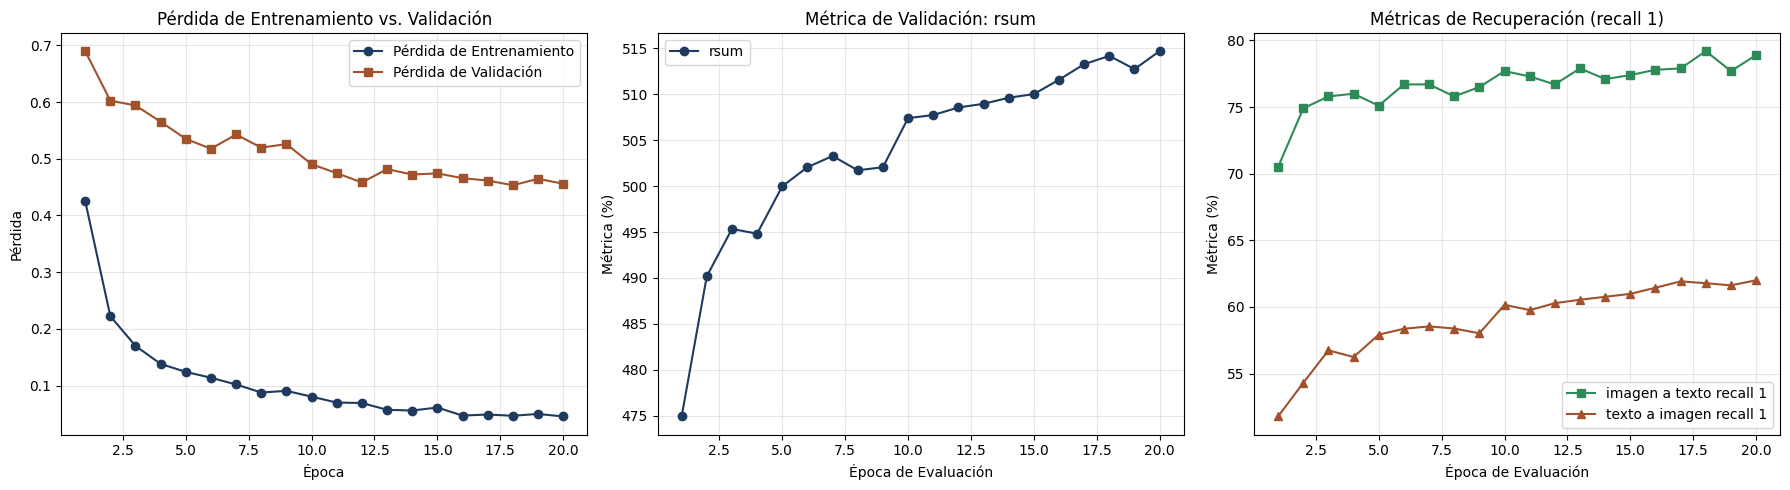

In [ ]:
total_epocas = len(historial["perdida_entren"])
epocas_entren = list(range(1, total_epocas + 1))
epocas_val = [e for e in range(1, total_epocas + 1) if e % CFG["eval_every"] == 0 or e == total_epocas]

if len(epocas_val) != len(historial["perdida_val"]):
    epocas_val = list(range(1, len(historial["perdida_val"]) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 0: Loss (Entrenamiento vs Validación)
axes[0].plot(epocas_entren, historial["perdida_entren"], "o-", label="Pérdida de Entrenamiento", color="#1E3A5F")
axes[0].plot(epocas_val,   historial["perdida_val"],   "s-", label="Pérdida de Validación",    color="#A0522D")
axes[0].set_title("Pérdida de Entrenamiento vs. Validación")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Pérdida")
axes[0].grid(alpha=.3)
axes[0].legend()

# Subplot 1: Solo rsum
axes[1].plot(epocas_val, historial["val_rsum"], "o-", label="rsum", color="#1E3A5F")
axes[1].set_title("Métrica de Validación: rsum")
axes[1].set_xlabel("Época de Evaluación")
axes[1].set_ylabel("Métrica (%)")
axes[1].grid(alpha=.3)
axes[1].legend()

# Subplot 2: Métricas imagen a texto y texto a imagen (recall 1)
axes[2].plot(epocas_val, historial["val_imagen a texto_recall1"], "s-", label="imagen a texto recall 1", color="#2E8B57")
axes[2].plot(epocas_val, historial["val_texto a imagen_recall1"], "^-", label="texto a imagen recall 1", color="#A0522D")
axes[2].set_title("Métricas de Recuperación (recall 1)")
axes[2].set_xlabel("Época de Evaluación")
axes[2].set_ylabel("Métrica (%)")
axes[2].grid(alpha=.3)
axes[2].legend()

plt.tight_layout()
plt.show()

Con respecto a la gráfica 1: La pérdida de entrenamiento cae de forma muy pronunciada desde la época 1 hasta aproximadamente la época 10, y luego se aplana cerca de 0.05. La pérdida de validación, en cambio, baja mucho más despacio y se estabiliza en torno a 0.47. Esta brecha grande y persistente entre ambas curvas es la señal más importante del gráfico: el modelo está sobreajustando (overfitting). Aprende muy bien los pares imagen-texto del entrenamiento, pero no generaliza con la misma eficacia en datos no vistos. Dado el tamaño reducido de Flickr8k (solo 6,000 imágenes de entrenamiento) frente a los millones con los que fue pre-entrenado CLIP, este comportamiento es esperable.

Con respecto a la gráfica 2: El rsum sube de aprox 481 en la época 1 hasta aprox 515 en la época 20, con una trayectoria ruidosa pero claramente ascendente. Esto indica que, a pesar del overfitting en la pérdida, el modelo sí mejora su capacidad de recuperación a lo largo del entrenamiento. El ruido entre épocas 7-10 sugiere cierta inestabilidad en ese tramo, probablemente cuando el learning rate del cosine scheduler todavía es relativamente alto.

## 9. Evaluación final del modelo

Una vez que el modelo ha sido entrenado, cargamos la mejor versión guardada y la probamos en un conjunto de datos completamente nuevo (test_ds). Esto nos da una idea real de cómo el modelo se desempeñará en situaciones nuevas y no vistas durante el entrenamiento.

Se carga el  modelo que obtuvo el mejor rendimiento en validación (según la métrica val_rsum) y se evalúa en el split de test. Este split consta de 1000 imágenes, cada una con 5 descripciones, lo que suma un total de 5000 pares de evaluación. Es importante reconstruir el modelo desde cero y cargar los pesos guardados, en lugar de continuar con la instancia en memoria, para evitar arrastrar estados internos del entrenamiento como los buffers de BatchNorm o el optimizador.

In [ ]:
modelo_ajustado, _, _ = open_clip.create_model_and_transforms(
    CFG["model_arch"], pretrained=CFG["model_pretrain"]
)
checkpoint = torch.load(str(ruta_mejor / "best.pt"), map_location="cpu")
modelo_ajustado.load_state_dict(checkpoint["state_dict"])
modelo_ajustado = modelo_ajustado.to(DEVICE).eval()
print(f"Checkpoint cargado - época {checkpoint['epoch']}  rsum_validación={checkpoint['val_rsum']:.2f}")

eval_ajustado = eval_retrieval(modelo_ajustado, datos_test, preprocess, tokenizer, etiqueta="eval_ajustado")
for k, v in eval_ajustado.items():
    print(f"{k:<22} {v:.2f}")

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Checkpoint cargado - época 20  rsum_validación=514.70


Codificando imágenes:   0%|          | 0/1000 [00:00<?, ?it/s]

Codificando textos:   0%|          | 0/40 [00:00<?, ?it/s]

eval_ajustado/imagen a texto_recall 1 75.90
eval_ajustado/imagen a texto_recall 5 91.70
eval_ajustado/imagen a texto_recall 10 96.00
eval_ajustado/imagen a texto_MedR 1.00
eval_ajustado/texto a imagen_recall 1 58.74
eval_ajustado/texto a imagen_recall 5 85.56
eval_ajustado/texto a imagen_recall 10 93.10
eval_ajustado/texto a imagen_MedR 1.00
eval_ajustado/rsum     501.00


Se construye un DataFrame que compara las métricas clave del modelo zero-shot (sin fine-tuning) con las del modelo fine-tuned. Incluye el delta en puntos porcentuales, que representa la mejora obtenida. Este análisis es fundamental para comprender el impacto del fine-tuning y validar si el entrenamiento adicional ha sido efectivo en nuestra tarea de búsqueda semántica imagen-texto.

In [ ]:
comparacion = pd.DataFrame({
    "Metrica"               : ["imagen a texto recall 1","imagen a texto recall 5","imagen a texto recall 10","texto a imagen recall 1","texto a imagen recall 5","texto a imagen recall 10","rsum"],
    "Zero-shot (CLIP-RN50)" : [eval_zeroshot[f"eval_zeroshot/{m}"] for m in ["imagen a texto_recall 1","imagen a texto_recall 5","imagen a texto_recall 10","texto a imagen_recall 1","texto a imagen_recall 5","texto a imagen_recall 10","rsum"]],
    "Fine-tuned"            : [eval_ajustado[f"eval_ajustado/{m}"] for m in ["imagen a texto_recall 1","imagen a texto_recall 5","imagen a texto_recall 10","texto a imagen_recall 1","texto a imagen_recall 5","texto a imagen_recall 10","rsum"]],
})
comparacion["Delta (pp)"] = (comparacion["Fine-tuned"] - comparacion["Zero-shot (CLIP-RN50)"]).round(2)
comparacion


,Metrica,Zero-shot (CLIP-RN50),Fine-tuned,Delta (pp)
0,imagen a texto recall 1,69.70,75.90,6.20
1,imagen a texto recall 5,89.80,91.70,1.90
2,imagen a texto recall 10,95.80,96.00,0.20
3,texto a imagen recall 1,51.40,58.74,7.34
4,texto a imagen recall 5,78.32,85.56,7.24
5,texto a imagen recall 10,87.00,93.10,6.10
6,rsum,472.02,501.00,28.98


## 10. Análisis cualitativo

Además de las métricas cuantitativas, es importante validar los resultados de forma visual. Esta sección realiza dos tipos de búsqueda semántica: de imagen a texto y de texto a imagen. En ambos casos se muestran los resultados más similares según el espacio de embeddings del modelo ajustado, lo que permite evaluar intuitivamente si el modelo comprende las relaciones entre imágenes y descripciones.

Codificando imágenes:   0%|          | 0/1000 [00:00<?, ?it/s]

Codificando textos:   0%|          | 0/40 [00:00<?, ?it/s]

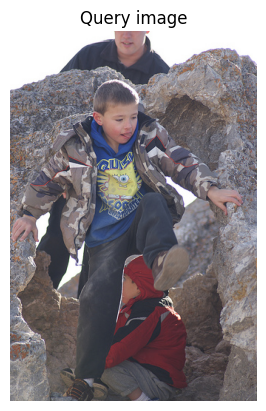

 1. [   ] A boy climbing a rocky area .
 2. [   ] A boy climbs up some rocks .
 3. [OK ] A boy climbs rocks .
 4. [   ] A young boy wearing a white hat is climbing rocks .
 5. [OK ] A boy crawls through a rock tunnel with his brother and father behind him .


In [ ]:
embs_imagen, embs_texto, img_a_descs = encode_all(modelo_ajustado, datos_test, preprocess, tokenizer)
todas_descripciones = [c for i in range(len(datos_test)) for c in get_caps(datos_test[i])]

def mostrar_imagen_a_texto(idx, k=5):
    ex = datos_test[idx]
    plt.imshow(get_image(ex)); plt.axis("off"); plt.title("Query image"); plt.show()
    sim = (embs_imagen[idx] @ embs_texto.T)
    topk = sim.topk(k).indices.tolist()
    correct = set(img_a_descs[idx])
    for j, ci in enumerate(topk, 1):
        mark = "OK " if ci in correct else "   "
        print(f" {j}. [{mark}] {todas_descripciones[ci]}")

mostrar_imagen_a_texto(random.randint(0, len(datos_test)-1))


Esta sección explora la búsqueda inversa, es decir, de texto a imagen. Se toma una descripción en inglés (ya que CLIP fue entrenado en inglés), se tokeniza, se calcula su embedding y se muestran las 5 imágenes más similares en una cuadrícula. Las consultas de ejemplo son frases descriptivas típicas de Flickr (como 'un perro saltando', 'un niño en bicicleta', o 'dos hombres jugando fútbol'). Esto permite verificar visualmente que el modelo comprende composiciones simples y puede recuperar imágenes relevantes.


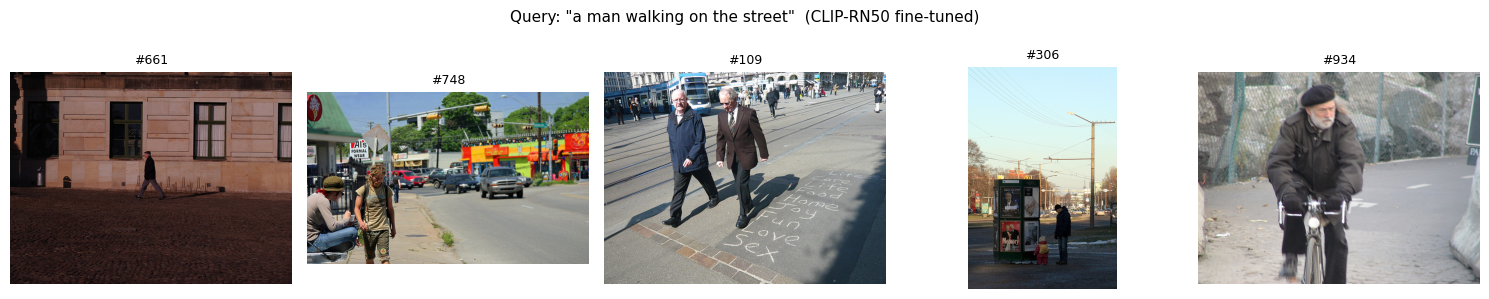

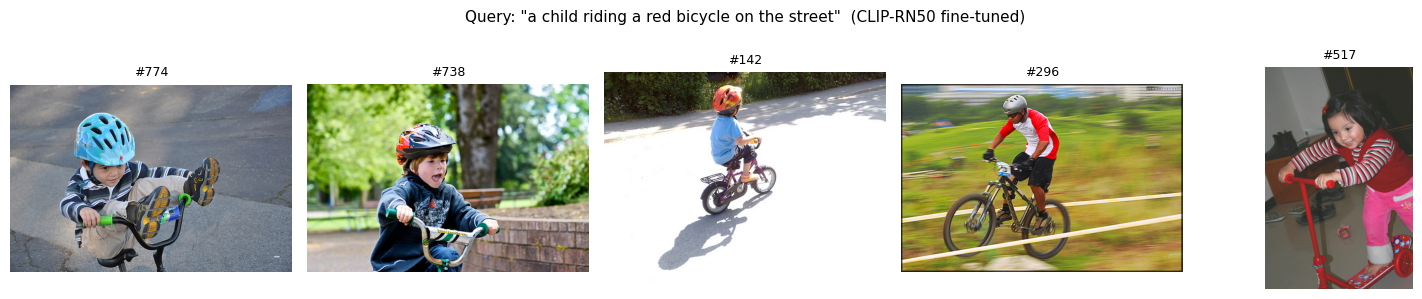

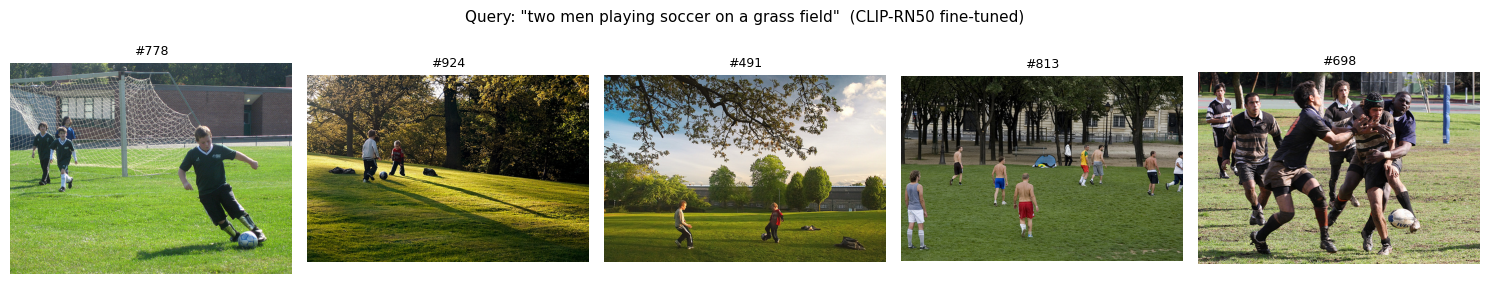

In [ ]:
@torch.no_grad()
def mostrar_texto_a_imagen(query, k=5):
    tok = tokenizer([query]).to(DEVICE)
    q   = modelo_ajustado.encode_text(tok).float()
    q   = F.normalize(q, dim=-1).cpu()
    sim = (q @ embs_imagen.T).squeeze()
    topk = sim.topk(k).indices.tolist()
    fig, axes = plt.subplots(1, k, figsize=(3*k, 3))
    for ax, ii in zip(axes, topk):
        ax.imshow(get_image(datos_test[ii])); ax.axis("off"); ax.set_title(f"#{ii}", fontsize=9)
    fig.suptitle(f'Query: "{query}"  (CLIP-RN50 fine-tuned)', fontsize=11)
    plt.tight_layout(); plt.show()

mostrar_texto_a_imagen("a man walking on the street")
mostrar_texto_a_imagen("a child riding a red bicycle on the street")
mostrar_texto_a_imagen("two men playing soccer on a grass field")